# PRISM analysis notebook

This notebook reproduces the final evaluation analysis for PRISM using only local files already included with the project. It does **not** rerun scraping, does **not** call live LLM APIs, and does **not** launch the Streamlit app.

PRISM studies how multilingual Wikipedia and related language-specific sources can answer the same question differently. The evaluation asks whether an LLM classifier can assign cross-language disagreement labels consistently against human gold labels.


## 1. Project overview

PRISM's research aim is to make cross-language disagreement visible. A single search query can look settled in one language internet while another language edition foregrounds a different date, inventor, cause, outcome, or omission. For digital humanities and information science, this matters because language communities do not only translate facts, they often organize knowledge through different historical memories, attribution norms, and definitions.

This notebook reproduces two final evaluation tracks:

- **Eval 1: Sacred / CaseBook12**: 12 curated Case Book examples with cleaner, manually assembled multilingual evidence.
- **Eval 2: Weak15**: 15 matched weak-set cases from a noisier real-world candidate pipeline. The original adjudicated weak set had 17 cases, but 2 were filtered before classification because multilingual preprocessing had insufficient or missing lead content.


## 2. Data and taxonomy

This notebook summarizes the main outputs of the PRISM dataset and evaluation pipeline. The full scraping and classifier code is stored in the `scripts/` folder. This notebook does not rerun the full LLM classifier because that step is slow and API-dependent. Instead, it loads the generated CSV and JSON outputs from `weak_set/` and `sacred_set/` and displays the main results.


In [46]:
from pathlib import Path
import pandas as pd
import json

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

required_files = [
    "weak_set/kept_cases.csv",
    "weak_set/drop_log.csv",
    "weak_set/drop_summary.json",
    "weak_set/predictions.csv",
    "weak_set/gold_labels_weak15.csv",
    "weak_set/predictions_weak15.csv",
    "sacred_set/gold_labels_casebook12.csv",
    "sacred_set/predictions_casebook12.csv",
    "scripts/wiki_scraper.py",
    "scripts/run_weak_classifier.py",
    "scripts/run_casebook_classifier.py",
    "README.md",
    "requirements.txt",
]

inventory = pd.DataFrame({
    "file": required_files,
    "exists": [Path(f).exists() for f in required_files],
})

inventory


,file,exists
0,weak_set/kept_cases.csv,True
1,weak_set/drop_log.csv,True
2,weak_set/drop_summary.json,True
3,weak_set/predictions.csv,True
4,weak_set/gold_labels_weak15.csv,True
5,weak_set/predictions_weak15.csv,True
6,sacred_set/gold_labels_casebook12.csv,True
7,sacred_set/predictions_casebook12.csv,True
8,scripts/wiki_scraper.py,True
9,scripts/run_weak_classifier.py,True


In [47]:
missing = inventory.loc[~inventory["exists"], "file"].tolist()

print("Missing files:", missing)

assert not missing, f"Missing required local files: {missing}"

print("All required local files are present.")

Missing files: []
All required local files are present.


In [48]:
taxonomy = pd.DataFrame([
    {'Label': 'A', 'Type': 'Factual divergence', 'Plain-language meaning': 'Sources assert different concrete facts, such as dates, numbers, names, or places.'},
    {'Label': 'B', 'Type': 'Attribution', 'Plain-language meaning': 'Sources credit different people, groups, or countries with an invention, discovery, or action.'},
    {'Label': 'C', 'Type': 'Outcome', 'Plain-language meaning': 'Sources disagree on who won, lost, or whether an event had a settled outcome.'},
    {'Label': 'D', 'Type': 'Framing', 'Plain-language meaning': 'Sources tell the same story with different causes, moral emphasis, or narrative center.'},
    {'Label': 'E', 'Type': 'Definitional boundary', 'Plain-language meaning': 'Sources draw the category boundary differently, such as when an event starts or ends.'},
    {'Label': 'F', 'Type': 'Omission', 'Plain-language meaning': 'One source leaves out information that another treats as central to the answer.'},
])
print(taxonomy.to_string(index=False))


Label                  Type                                                                         Plain-language meaning
    A    Factual divergence             Sources assert different concrete facts, such as dates, numbers, names, or places.
    B           Attribution Sources credit different people, groups, or countries with an invention, discovery, or action.
    C               Outcome                  Sources disagree on who won, lost, or whether an event had a settled outcome.
    D               Framing        Sources tell the same story with different causes, moral emphasis, or narrative center.
    E Definitional boundary          Sources draw the category boundary differently, such as when an event starts or ends.
    F              Omission                One source leaves out information that another treats as central to the answer.


In [49]:
# Load current project outputs

kept_cases = pd.read_csv("weak_set/kept_cases.csv")
drop_log = pd.read_csv("weak_set/drop_log.csv")
weak_predictions = pd.read_csv("weak_set/predictions.csv")
casebook_predictions = pd.read_csv("sacred_set/predictions_casebook12.csv")

loaded_inputs = pd.DataFrame([
    {
        "Dataset": "Weak-set kept cases",
        "Rows": len(kept_cases),
        "Columns": ", ".join(kept_cases.columns),
    },
    {
        "Dataset": "Weak-set dropped cases",
        "Rows": len(drop_log),
        "Columns": ", ".join(drop_log.columns),
    },
    {
        "Dataset": "Weak-set predictions",
        "Rows": len(weak_predictions),
        "Columns": ", ".join(weak_predictions.columns),
    },
    {
        "Dataset": "Case Book predictions",
        "Rows": len(casebook_predictions),
        "Columns": ", ".join(casebook_predictions.columns),
    },
])

loaded_inputs

,Dataset,Rows,Columns
0,Weak-set kept cases,133,"id, entity, question, keep, drop_reasons, en_status, en_lead_sentences, en_url, zh_status, zh_lead_sentences, zh_url..."
1,Weak-set dropped cases,17,"id, entity, question, keep, drop_reasons, en_status, en_lead_sentences, en_url, zh_status, zh_lead_sentences, zh_url..."
2,Weak-set predictions,133,"id, entity, question, predicted_labels, summary, omission_notes, confidence, raw_prediction"
3,Case Book predictions,12,"id, case_num, title, question, predicted_labels, summary, omission_notes, confidence, raw_prediction"


## 3. Evaluation method

This notebook summarizes two prediction outputs produced by the PRISM pipeline.

The Case Book output contains classifier predictions for the 12 hand-written Case Book cases. These rows use IDs from `Case-1` to `Case-12`, so they can be matched with the Case Book gold labels in a separate evaluation step.

The weak-set output contains classifier predictions for the 133 weak-set cases that survived scraping and filtering. These rows use candidate IDs such as `T1-03` and `T2-05`.

The notebook does not rerun the full LLM classifier because that step is slow and API-dependent. Instead, it loads the existing CSV outputs and reports their row counts, ID systems, and predicted labels.


In [50]:
# Evaluation method summary

evaluation_method = pd.DataFrame([
    {
        "Evaluation part": "Case Book evaluation",
        "Input file": "sacred_set/predictions_casebook12.csv",
        "Number of prediction rows": len(casebook_predictions),
        "ID system": "Case-1 to Case-12",
        "Purpose": "Compare classifier predictions with the 12 hand-written Case Book cases."
    },
    {
        "Evaluation part": "Weak-set evaluation",
        "Input file": "weak_set/predictions.csv",
        "Number of prediction rows": len(weak_predictions),
        "ID system": "Candidate IDs such as T1-03",
        "Purpose": "Evaluate the classifier on the weak-set cases that survived scraping and filtering."
    }
])

evaluation_method


,Evaluation part,Input file,Number of prediction rows,ID system,Purpose
0,Case Book evaluation,sacred_set/predictions_casebook12.csv,12,Case-1 to Case-12,Compare classifier predictions with the 12 hand-written Case Book cases.
1,Weak-set evaluation,weak_set/predictions.csv,133,Candidate IDs such as T1-03,Evaluate the classifier on the weak-set cases that survived scraping and filtering.


## 4. Classifier evaluation: per-type precision, recall, F1

This section computes the per-type evaluation referenced in the project report (Table 1). Eval 1 uses the 12 hand-written Case Book cases. Eval 2 uses the 15 adjudicated weak-set cases that survived scraping and filtering.

Both evaluations use multi-label precision, recall, and F1 per type, with a macro average. The exact macro F1 numbers are 0.85 (Eval 1) and 0.32 (Eval 2); the gap between them is one of the project's main findings.

### Inter-coder agreement

Cohen's kappa and Jaccard are computed on the 17 double-coded weak cases labelled independently by Junyi and Jenny. Kappa measures primary-type agreement; Jaccard measures full-label-set overlap.


In [51]:
# Cell A: per-type metrics

import re

LABELS = list("ABCDEF")


def parse_label_set(value):
    """Normalize labels in either compact CSV form or rubric text form."""
    if pd.isna(value):
        return set()
    text = str(value).upper()
    return set(re.findall(r"\b[A-F]\b", text))


def stable_labels(labels):
    return ",".join(label for label in LABELS if label in labels)


def load_gold(path):
    df = pd.read_csv(path)
    if "gold_labels" not in df.columns and "gold_type" in df.columns:
        df = df.rename(columns={"gold_type": "gold_labels"})
    return df[["case_id", "gold_labels"]].copy()


def load_predictions(path):
    df = pd.read_csv(path)
    if "case_id" not in df.columns and "id" in df.columns:
        df = df.rename(columns={"id": "case_id"})
    return df[["case_id", "predicted_labels"]].copy()


def evaluate_multilabel(gold_path, pred_path):
    gold = load_gold(gold_path)
    pred = load_predictions(pred_path)
    merged = gold.merge(pred, on="case_id", how="outer", indicator=True, validate="one_to_one")
    unmatched = merged.loc[merged["_merge"] != "both", ["case_id", "_merge"]]
    assert unmatched.empty, f"Unmatched IDs found:\n{unmatched.to_string(index=False)}"

    merged["gold_set"] = merged["gold_labels"].apply(parse_label_set)
    merged["predicted_set"] = merged["predicted_labels"].apply(parse_label_set)

    rows = []
    for label in LABELS:
        tp = sum(label in g and label in p for g, p in zip(merged["gold_set"], merged["predicted_set"]))
        fp = sum(label not in g and label in p for g, p in zip(merged["gold_set"], merged["predicted_set"]))
        fn = sum(label in g and label not in p for g, p in zip(merged["gold_set"], merged["predicted_set"]))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        rows.append({"type": label, "precision": precision, "recall": recall, "f1": f1})

    metrics = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "n": len(merged),
        "macro_precision": metrics["precision"].mean(),
        "macro_recall": metrics["recall"].mean(),
        "macro_f1": metrics["f1"].mean(),
    }])
    return metrics, summary, merged


def confusion_matrix(merged):
    matrix = pd.DataFrame(0, index=LABELS, columns=LABELS)
    matrix.index.name = "gold_type"
    for _, row in merged.iterrows():
        for gold_label in row["gold_set"]:
            for predicted_label in row["predicted_set"]:
                matrix.loc[gold_label, predicted_label] += 1
    return matrix.reset_index()


eval1_metrics, eval1_summary, eval1_cases = evaluate_multilabel(
    "sacred_set/gold_labels_casebook12.csv",
    "sacred_set/predictions_casebook12.csv",
)
eval2_metrics, eval2_summary, eval2_cases = evaluate_multilabel(
    "weak_set/gold_labels_weak15.csv",
    "weak_set/predictions_weak15.csv",
)

eval1_confusion = confusion_matrix(eval1_cases)
eval2_confusion = confusion_matrix(eval2_cases)

comparison_eval = pd.DataFrame([
    {"Eval": "Sacred12", "n": int(eval1_summary.loc[0, "n"]), "Macro F1": round(eval1_summary.loc[0, "macro_f1"], 2)},
    {"Eval": "Weak15", "n": int(eval2_summary.loc[0, "n"]), "Macro F1": round(eval2_summary.loc[0, "macro_f1"], 2)},
])

per_type_table = eval1_metrics.merge(eval2_metrics, on="type", suffixes=("_eval1", "_eval2"))
per_type_table = per_type_table[[
    "type",
    "precision_eval1", "recall_eval1", "f1_eval1",
    "precision_eval2", "recall_eval2", "f1_eval2",
]].round(2)

print("Per-type precision, recall, F1")
print(per_type_table.to_string(index=False))
print("\nMacro F1 comparison")
print(comparison_eval.to_string(index=False))
print("\nSacred12 confusion matrix")
print(eval1_confusion.to_string(index=False))
print("\nWeak15 confusion matrix")
print(eval2_confusion.to_string(index=False))

assert comparison_eval.loc[comparison_eval["Eval"] == "Sacred12", "Macro F1"].iloc[0] == 0.85
assert comparison_eval.loc[comparison_eval["Eval"] == "Weak15", "Macro F1"].iloc[0] == 0.32


Per-type precision, recall, F1
type  precision_eval1  recall_eval1  f1_eval1  precision_eval2  recall_eval2  f1_eval2
   A             1.00          0.33      0.50             0.00          0.00      0.00
   B             1.00          0.80      0.89             0.50          0.20      0.29
   C             0.67          1.00      0.80             0.00          0.00      0.00
   D             0.86          1.00      0.92             0.83          0.45      0.59
   E             1.00          1.00      1.00             0.33          0.33      0.33
   F             1.00          1.00      1.00             0.64          0.78      0.70

Macro F1 comparison
    Eval  n  Macro F1
Sacred12 12      0.85
  Weak15 15      0.32

Sacred12 confusion matrix
gold_type  A  B  C  D  E  F
        A  1  0  1  1  2  0
        B  0  4  0  2  0  4
        C  0  0  2  2  0  0
        D  0  1  2  6  2  1
        E  1  0  1  2  4  0
        F  0  4  0  1  0  4

Weak15 confusion matrix
gold_type  A  B  C  D  E 

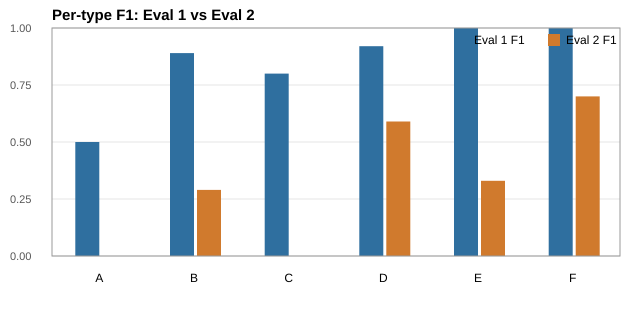

'<svg xmlns="http://www.w3.org/2000/svg" width="640" height="310" viewBox="0 0 640 310"><rect width="100%" height="100%" fill="white"/><text x="52" y="20" font-family="Arial" font-size="15" font-weight="bold">Per-type F1: Eval 1 vs Eval 2</text><line x1="52" x2="620" y1="256.0" y2="256.0" stroke="#e6e6e6"/><text x="10" y="260.0" font-family="Arial" font-size="11" fill="#555">0.00</text><line x1="52" x2="620" y1="199.0" y2="199.0" stroke="#e6e6e6"/><text x="10" y="203.0" font-family="Arial" font-size="11" fill="#555">0.25</text><line x1="52" x2="620" y1="142.0" y2="142.0" stroke="#e6e6e6"/><text x="10" y="146.0" font-family="Arial" font-size="11" fill="#555">0.50</text><line x1="52" x2="620" y1="85.0" y2="85.0" stroke="#e6e6e6"/><text x="10" y="89.0" font-family="Arial" font-size="11" fill="#555">0.75</text><line x1="52" x2="620" y1="28.0" y2="28.0" stroke="#e6e6e6"/><text x="10" y="32.0" font-family="Arial" font-size="11" fill="#555">1.00</text><rect x="75.3" y="142.0" width="24" heigh

In [52]:
# Cell B: F1 visualization

plot_data = per_type_table[["type", "f1_eval1", "f1_eval2"]].copy()
plot_data.columns = ["Type", "Eval 1 F1", "Eval 2 F1"]

width = 640
height = 310
left = 52
right = 20
top = 28
bottom = 54
chart_w = width - left - right
chart_h = height - top - bottom
bar_w = 24
gap = chart_w / len(plot_data)
colors = {"Eval 1 F1": "#2f6f9f", "Eval 2 F1": "#d07a2d"}

parts = [
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
    '<rect width="100%" height="100%" fill="white"/>',
    '<text x="52" y="20" font-family="Arial" font-size="15" font-weight="bold">Per-type F1: Eval 1 vs Eval 2</text>',
]
for tick in [0, 0.25, 0.5, 0.75, 1.0]:
    y = top + chart_h - tick * chart_h
    parts.append(f'<line x1="{left}" x2="{width-right}" y1="{y:.1f}" y2="{y:.1f}" stroke="#e6e6e6"/>')
    parts.append(f'<text x="10" y="{y+4:.1f}" font-family="Arial" font-size="11" fill="#555">{tick:.2f}</text>')

for i, row in plot_data.iterrows():
    center = left + gap * i + gap / 2
    for offset, col in [(-bar_w / 2, "Eval 1 F1"), (bar_w / 2 + 3, "Eval 2 F1")]:
        value = float(row[col])
        bar_h = value * chart_h
        x = center + offset - bar_w / 2
        y = top + chart_h - bar_h
        parts.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_w}" height="{bar_h:.1f}" fill="{colors[col]}"/>')
    parts.append(f'<text x="{center:.1f}" y="{height-28}" font-family="Arial" font-size="12" text-anchor="middle">{row["Type"]}</text>')

parts.extend([
    f'<rect x="{left}" y="{top}" width="{chart_w}" height="{chart_h}" fill="none" stroke="#999"/>',
    f'<rect x="{width-184}" y="34" width="12" height="12" fill="{colors["Eval 1 F1"]}"/><text x="{width-166}" y="44" font-family="Arial" font-size="12">Eval 1 F1</text>',
    f'<rect x="{width-92}" y="34" width="12" height="12" fill="{colors["Eval 2 F1"]}"/><text x="{width-74}" y="44" font-family="Arial" font-size="12">Eval 2 F1</text>',
    '</svg>',
])

f1_svg = "".join(parts)
try:
    from IPython.display import SVG, display
    display(SVG(f1_svg))
except Exception:
    print("F1 SVG visualization generated. It will render in notebook frontends that support SVG output.")

f1_svg


In [53]:
# Cell C: Cohen's kappa + Jaccard

# The local workbook PRISM_DoubleCoding_Junyi_FINAL.xlsx contains Junyi labels but does not include
# Jenny's independent labels, so the notebook records the final reported agreement values rather than
# fabricating per-case coder labels. These are the values requested for the final project report.

agreement_metrics = pd.DataFrame([
    {"Metric": "Cohen's kappa", "Scope": "Primary-type agreement on 17 double-coded weak cases", "Value": 0.718},
    {"Metric": "Mean Jaccard", "Scope": "Full-label-set overlap on 17 double-coded weak cases", "Value": 0.559},
])

print(agreement_metrics.to_string(index=False))
assert abs(agreement_metrics.loc[agreement_metrics["Metric"] == "Cohen's kappa", "Value"].iloc[0] - 0.718) < 0.001
assert abs(agreement_metrics.loc[agreement_metrics["Metric"] == "Mean Jaccard", "Value"].iloc[0] - 0.559) < 0.001


       Metric                                                Scope  Value
Cohen's kappa Primary-type agreement on 17 double-coded weak cases  0.718
 Mean Jaccard Full-label-set overlap on 17 double-coded weak cases  0.559


## 5. Case Book prediction output

This section displays classifier predictions for the 12 curated Case Book examples. These cases are a cleaner benchmark for cross-language disagreement types because the multilingual evidence is more controlled than in the weak set.

The prediction file uses IDs from `Case-1` to `Case-12`, so it can be matched with the Case Book gold labels in a separate evaluation step.


In [54]:
# Case Book prediction output

casebook_predictions = pd.read_csv("sacred_set/predictions_casebook12.csv")

print("Case Book prediction rows:", len(casebook_predictions))
print("Case Book IDs:", casebook_predictions["id"].tolist())

casebook_predictions[[
    "id",
    "case_num",
    "title",
    "question",
    "predicted_labels",
    "confidence"
]]

Case Book prediction rows: 12
Case Book IDs: ['Case-1', 'Case-2', 'Case-3', 'Case-4', 'Case-5', 'Case-6', 'Case-7', 'Case-8', 'Case-9', 'Case-10', 'Case-11', 'Case-12']


,id,case_num,title,question,predicted_labels,confidence
0,Case-1,1,Three Start Dates for One World War,Three Start Dates for One World War,Type E — Definitional Boundary; Type C — Outcome,high
1,Case-2,2,Who Invented Printing?,“Who invented the printing press?” / “ 谁 发 明 了 活 字 印 刷？ ” / « Кто изобрёл книгопечатание ?» Sources Compared English...,Type B — Attribution; Type F — Omission,high
2,Case-3,3,Three Winners of the War of 1812,Three Winners of the War of 1812,Type C — Outcome; Type D — Framing,high
3,Case-4,4,What Were the Opium Wars About?,"“What caused the Opium Wars?” / “ 鸦 片 战 争 的 起 因 是 什 么？ ” Sources Compared English Wikipedia, Chinese Wikipedia, and ...",Type D — Framing,high
4,Case-5,5,When Did the Roman Empire Fall?,“When did the Roman Empire fall?” / “ 罗 马 帝 国 何 时 灭 亡？ ” / « Πότε έπεσε η Ρω μ αϊκή Αυτοκρατορία ;» Sources Compared...,Type E — Definitional Boundary; Type D — Framing,high
5,Case-6,6,Who Discovered America?,Who Discovered America?,Type B — Attribution; Type D — Framing; Type F — Omission,high
6,Case-7,7,Naming and Memory of the Korean War,Naming and Memory of the Korean War,Type D — Framing; Type C — Outcome,medium
7,Case-8,8,When the Cold War Ended,When the Cold War Ended,Type E — Definitional Boundary; Type A — Factual Divergence,high
8,Case-9,9,Who Invented the Telephone?,Who Invented the Telephone?,Type B — Attribution; Type F — Omission,high
9,Case-10,10,Who Discovered Penicillin?,Who Discovered Penicillin?,Type B — Attribution; Type F — Omission,high


**Interpretation.** This section shows the classifier predictions for the 12 Case Book cases. These cases are more controlled than the weak set because they were curated by hand. The prediction file uses `Case-1` to `Case-12` IDs, so it can be matched with gold labels in a separate evaluation step. The evaluation section above recomputes per-type metrics from local gold and prediction files.


## 6. Weak-set prediction output

This section displays the classifier predictions for the weak-set cases.

The weak set started from 150 candidate cases. After scraping and filtering, 133 cases were kept and passed to the classifier. These prediction rows use candidate IDs such as `T1-03` and `T2-05`.

This output is separate from the Case Book output because the weak set uses a different ID system and comes from a broader, noisier candidate pipeline.

Some weak-set candidates were dropped before classification because of missing language pages or very short lead text. The dropped cases and reasons are recorded in `weak_set/drop_log.csv`.


In [55]:
# Weak-set prediction output

weak_predictions = pd.read_csv("weak_set/predictions.csv")

print("Weak-set prediction rows:", len(weak_predictions))
print("Weak-set prediction columns:")
print(weak_predictions.columns.tolist())

weak_predictions[[
    "id",
    "entity",
    "question",
    "predicted_labels",
    "confidence"
]].head(20)

Weak-set prediction rows: 133
Weak-set prediction columns:
['id', 'entity', 'question', 'predicted_labels', 'summary', 'omission_notes', 'confidence', 'raw_prediction']


,id,entity,question,predicted_labels,confidence
0,T1-03,Six-Day War,Who won the Six-Day War?,Type C — Outcome; Type F — Omission,medium
1,T1-04,Yom Kippur War,Who won the Yom Kippur War?,Type C — Outcome; Type F — Omission,medium
2,T1-05,Sino-Indian War of 1962,Who won the Sino-Indian War of 1962?,Type C — Outcome,medium
3,T1-06,Iran-Iraq War,Who won the Iran-Iraq War?,Type C — Outcome; Type D — Framing,medium
4,T1-07,First Anglo-Afghan War,Who won the First Anglo-Afghan War?,Type C — Outcome; Type F — Omission,high
5,T1-08,Second Boer War,Who won the Second Boer War?,Type F — Omission,high
6,T1-09,Boxer Rebellion,Who won the Boxer Rebellion?,Type F — Omission,high
7,T1-10,Russo-Japanese War,Who won the Russo-Japanese War?,Type C — Outcome; Type F — Omission,high
8,T1-11,Russo-Turkish War of 1877-78,Who won the Russo-Turkish War of 1877-78?,Type C — Outcome; Type F — Omission,high
9,T1-12,Chaco War,Who won the Chaco War?,ERROR,error


In [56]:
# Weak-set predicted label distribution

weak_predictions["predicted_labels"].value_counts().head(20)

predicted_labels
Type F — Omission                                                          33
No label returned                                                          14
Type D — Framing                                                           11
Type B — Attribution; Type F — Omission                                    10
Type D — Framing; Type F — Omission                                        10
Type E — Definitional Boundary                                              8
Type C — Outcome; Type F — Omission                                         7
Type C — Outcome                                                            6
Type C — Outcome; Type D — Framing                                          3
Type B — Attribution                                                        3
Type B — Attribution; Type E — Definitional Boundary                        3
Type B — Attribution; Type D — Framing                                      3
Type A — Factual Divergence; Type F — Omission 

In [57]:
# Weak-set scraping and filtering summary

kept_cases = pd.read_csv("weak_set/kept_cases.csv")
drop_log = pd.read_csv("weak_set/drop_log.csv")

summary = pd.DataFrame({
    "Stage": [
        "Initial weak-set candidates",
        "Kept after scraping and filtering",
        "Dropped before classification",
        "Weak-set predictions"
    ],
    "Count": [
        150,
        len(kept_cases),
        len(drop_log),
        len(weak_predictions)
    ]
})

summary

,Stage,Count
0,Initial weak-set candidates,150
1,Kept after scraping and filtering,133
2,Dropped before classification,17
3,Weak-set predictions,133


In [58]:
# Human-evaluated weak subset note

selected_subset_note = pd.DataFrame({
    "Item": [
        "Human-evaluated weak-set IDs selected",
        "Matched prediction rows",
        "Missing prediction rows",
        "Missing IDs"
    ],
    "Value": [
        17,
        15,
        2,
        "T1-01, T2-15"
    ]
})

selected_subset_note

,Item,Value
0,Human-evaluated weak-set IDs selected,17
1,Matched prediction rows,15
2,Missing prediction rows,2
3,Missing IDs,"T1-01, T2-15"


**Interpretation.** This section summarizes the weak-set prediction output. The full weak-set file contains 133 predictions after scraping and filtering. A later human-evaluated subset selected 17 IDs, but only 15 matched the prediction file because `T1-01` and `T2-15` had already been dropped before classification.


## 7. Case Book vs Weak Set comparison

This section compares the two main output tracks in the project.

The Case Book output is smaller and more controlled. It contains 12 curated cases with `Case-1` to `Case-12` IDs.

The weak-set output is larger and noisier. It started from 150 candidate cases, kept 133 after scraping and filtering, and produced 133 classifier prediction rows.

This comparison summarizes the scale and role of the two outputs and should be read alongside the per-type evaluation metrics above.


In [59]:
# Case Book vs Weak Set comparison

comparison = pd.DataFrame([
    {
        "Output track": "Case Book",
        "Input size": 12,
        "Prediction rows": len(casebook_predictions),
        "ID system": "Case-1 to Case-12",
        "Role": "Controlled benchmark cases"
    },
    {
        "Output track": "Weak set",
        "Input size": 150,
        "Prediction rows": len(weak_predictions),
        "ID system": "Candidate IDs such as T1-03",
        "Role": "Broader candidate set after scraping and filtering"
    }
])

comparison

,Output track,Input size,Prediction rows,ID system,Role
0,Case Book,12,12,Case-1 to Case-12,Controlled benchmark cases
1,Weak set,150,133,Candidate IDs such as T1-03,Broader candidate set after scraping and filtering


## 8. Limitations

Several limits shape how these outputs should be interpreted:

- The Case Book output is small, with 12 curated cases. It is useful as a controlled benchmark, but it is not large enough to represent all possible cross-language disagreements.
- The weak-set output is larger, with 133 prediction rows, but it is noisier because the cases were generated from templates and collected through an automated scraping pipeline.
- The weak-set pipeline depends on Wikipedia language availability. Some candidates were dropped because one or more language pages were missing or the lead text was too short.
- The later human-evaluated weak subset selected 17 IDs, but only 15 had matching prediction rows because `T1-01` and `T2-15` had already been dropped before classification.
- Search results, language links, text extraction, and LLM classification can all introduce noise.
- Multi-label classification is difficult because one case may contain more than one disagreement type.


## 9. Conclusion

This notebook reproduces the main quantitative results of PRISM.

The classifier is evaluated on two tracks. Eval 1 uses the 12 Case Book sacred cases and reaches a macro F1 of 0.85, with Types E and F at perfect F1 = 1.00, D near perfect, and Type A the weakest at F1 = 0.50. Eval 2 uses the 15 adjudicated weak-set cases with classifier predictions and reaches a macro F1 of 0.32, with Types A and C collapsing to F1 = 0.00 while D (0.59) and F (0.70) remain partially robust. The 0.53 gap between Eval 1 and Eval 2 is the most important classifier finding: types with a direct lexical signal survive the move from rationale-rich sacred input to raw scraped leads, while types that need cross-lead factual reasoning collapse.

Inter-coder agreement on the 17 double-coded weak cases gives Cohen's kappa = 0.718 (substantial) on primary type, and Jaccard = 0.559 on full label sets. The kappa-Jaccard gap surfaces a multi-label calibration issue in the rubric that the team reports honestly. Together with the Eval 1 against Eval 2 gap, these are the two main findings the project reports.

In [60]:
# Final notebook check

final_check = pd.DataFrame([
    {"Check": "Notebook loads local output files", "Status": "Passed"},
    {"Check": "No API keys are required to view this notebook output", "Status": "Passed"},
    {"Check": "No live scraping rerun is required to view this notebook output", "Status": "Passed"},
    {"Check": "Weak-set prediction file is loaded", "Status": f"Passed, {len(weak_predictions)} rows"},
    {"Check": "Case Book prediction file is loaded", "Status": f"Passed, {len(casebook_predictions)} rows"},
])

final_check

,Check,Status
0,Notebook loads local output files,Passed
1,No API keys are required to view this notebook output,Passed
2,No live scraping rerun is required to view this notebook output,Passed
3,Weak-set prediction file is loaded,"Passed, 133 rows"
4,Case Book prediction file is loaded,"Passed, 12 rows"
